DO: per unit CCG around oscillations, see if some region pairs have temporality

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import xarray as xr

import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [49]:
def _unitCCG(session,regs=None,when='sleep.*#0',conds=None,bin=0.05,n_bins=25,window=20,shuffle=0,baseline=None):
    # n_bins: bin centered on 0 + n_bins-1 bins in the right, window: n of first bins in which max is taken

    # load data
    R = fma.regions.regions(session,phases=when,states=['sws','rem'],events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    events = isau.loadHpcPfcEvents(session)

    spikes = R.spikes(regs=regs)
    unit_unique, unit_reg = R.units(regs=regs,return_reg=True)

    conditions = {'nrem': R.eventIntervals('sws'), 'rem': R.eventIntervals('rem'), 'wake': R.eventIntervals('other'),
                  'isa': R.eventIntervals('slownr'), 'nisa': R.eventIntervals([['sws','/slownr']])}
    lim_oscill = [[-1,1],[-1,1],[-3,3]]
    for i, e in enumerate(events):
        conditions[e] = events[e][:,None] + lim_oscill[i]
    if conds is None: conds = list(conditions.keys())

    def ccg_f(s):
        return fma.analysis.CCG(s,bin,limits=(-bin/2,bin/2+bin*n_bins),fast=True,norm='rate')

    ccg = []
    ccg_baseline = []
    for condition in conds:
        ccg.append([])
        # observed
        s = fma.general.restrict(spikes,conditions[condition])
        c, t = ccg_f(s)
        ccg[-1].append(c)
        # surrogate
        for k in range(shuffle):
            s_sh = fma.general.jitter(s,dt=2*bin) #np.max(np.abs(limits))
            c, t = ccg_f(s_sh)
            ccg[-1].append(c)
        # baseline
        if baseline is not None:
            c, _ = ccg_f(s)
            ccg_baseline.append(c)
    ccg = np.array(ccg)
    ccg_baseline = np.array(ccg_baseline)

    # peak times with random tie breaking
    peak = ccg[:,:,:,:,:window].max(axis=-1)
    ties = ccg[:,:,:,:,:window] == peak[:,:,:,:,None]
    scores = np.where(ties,np.random.random(ccg.shape[:-1] + (window,)),-1.0)
    peak_t = t[np.argmax(scores,axis=-1)]

    # significance of peaks
    peak = np.permute_dims(peak,(1,0,2,3))
    signif = fma.analysis.MCpValue(peak[1:],peak[0],alternative='greater') < 0.05

    shuffle = [False] + [True] * shuffle # make coordinate
    ccg = xr.DataArray(ccg,dims=['cond','shuf','reg0','reg1','t'],coords={'cond': conds, 'shuf': shuffle, 'reg0': unit_reg, 'reg1': unit_reg, 't': t, 'rat': int(R.rat)})
    peak_t = xr.DataArray(peak_t,dims=['cond','shuf','reg0','reg1'],coords={'cond': conds, 'shuf': shuffle, 'reg0': unit_reg, 'reg1': unit_reg,
                          'signif': (['cond','reg0','reg1'],signif), 'rat': int(R.rat)})
    if baseline is not None:
        T = np.abs(ccg.sel(shuf=False) - ccg.sel(shuf=False).mean(axis=-1)).max(axis=-1) / ccg_baseline.std(axis=-1)
        T = xr.DataArray(T,dims=['cond','reg0','reg1'],coords={'cond': conds, 'reg0': unit_reg, 'reg1': unit_reg, 'rat': int(R.rat)})
        signif = xr.zeros_like(T,dtype=bool)
        for r0 in regs:
            for r1 in regs:
                this_T = T.sel(reg0=r0,reg1=r1)
                signif.loc[{'reg0': r0, 'reg1': r1}] = this_T > np.nanpercentile(this_T.values,80,axis=(1,2))[:,None,None]

        return ccg, peak_t, T, signif

    return ccg, peak_t

In [50]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][14]
print(session)
regs = ['hpc','nr','pfc']
bin = 0.005
sccg, speak_t = _unitCCG(session,regs=regs,conds=['isa','nisa','nrem','rem','wake'],shuffle=20,bin=bin) # , sT, ssignif

/mnt/hubel-data-139/karadoc/Rat004_20240226/Rat004_20240226.xml


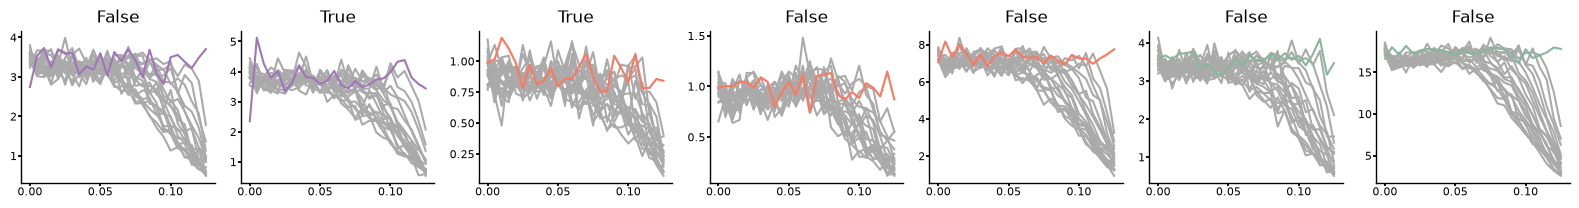

In [65]:
# see examples
conditions = ['nrem']
r0 = 'hpc'
k = 23
fig, ax = fma.plotting.makeFigure(n=(1,7),size=(40,5))
for i, j in enumerate(np.sort(np.random.choice(len(sccg.reg0),7,replace=False))):
    tit = ''
    for c, cond in enumerate(conditions):
        data = sccg.sel(cond=cond).isel(reg0=k,reg1=j)
        #tit = f'{sT.sel(cond=cond,reg0=r0).isel(reg1=j)[k]:.2f} {ssignif.sel(cond=cond,reg0=r0).isel(reg1=j)[k].values}'
        #fma.plotting.semPlot(sccg.t,data.sel(shuf=True),color=isau.paperColors('shuffle'),ax=ax[i])
        ax[i].plot(sccg.t,data.sel(shuf=True).T,color=isau.paperColors('shuffle'))

        ax[i].plot(sccg.t,data.sel(shuf=False),color=isau.paperColors(str(data.reg1.values)))

        tit += f'{speak_t.signif.sel(cond=cond).isel(reg0=k,reg1=j).values}'
    ax[i].set(title=tit)

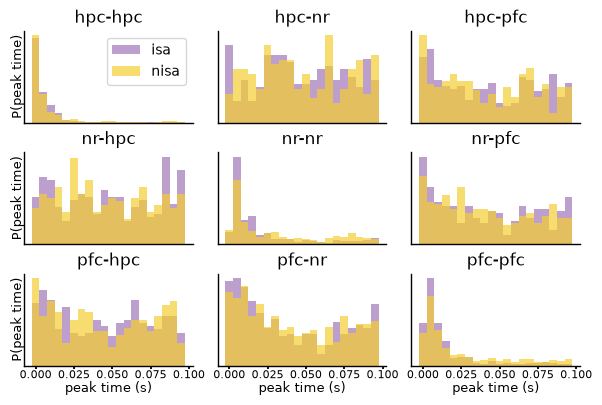

In [70]:
# plot peak times
cond = ['isa','nisa']
#cond = ['nrem','rem']
colors = ['nr','shuffl']
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(n=(n_regs,n_regs),size=(15,10))
for k, c in enumerate(cond):
    for i, r0 in enumerate(regs):
        for j, r1 in enumerate(regs):
            ax[i,j].set(title=f'{r0}-{r1}')
            data = speak_t.sel(cond=c,reg0=r0,reg1=r1,shuf=False).values.ravel()[speak_t.signif.sel(cond=c,reg0=r0,reg1=r1).values.ravel()]
            x, y = fma.plotting.plotPDF(data,method='discrete',ax=ax[i,j],color=isau.paperColors(colors[k]),alpha=.7,label=c) #,norm='cdf'
ax[0,0].legend(); fma.plotting.setProp(ax[:-1],xticks=[]); fma.plotting.setProp(ax[-1],xlabel='peak time (s)'); fma.plotting.setProp(ax[:,0],ylabel='P(peak time)')

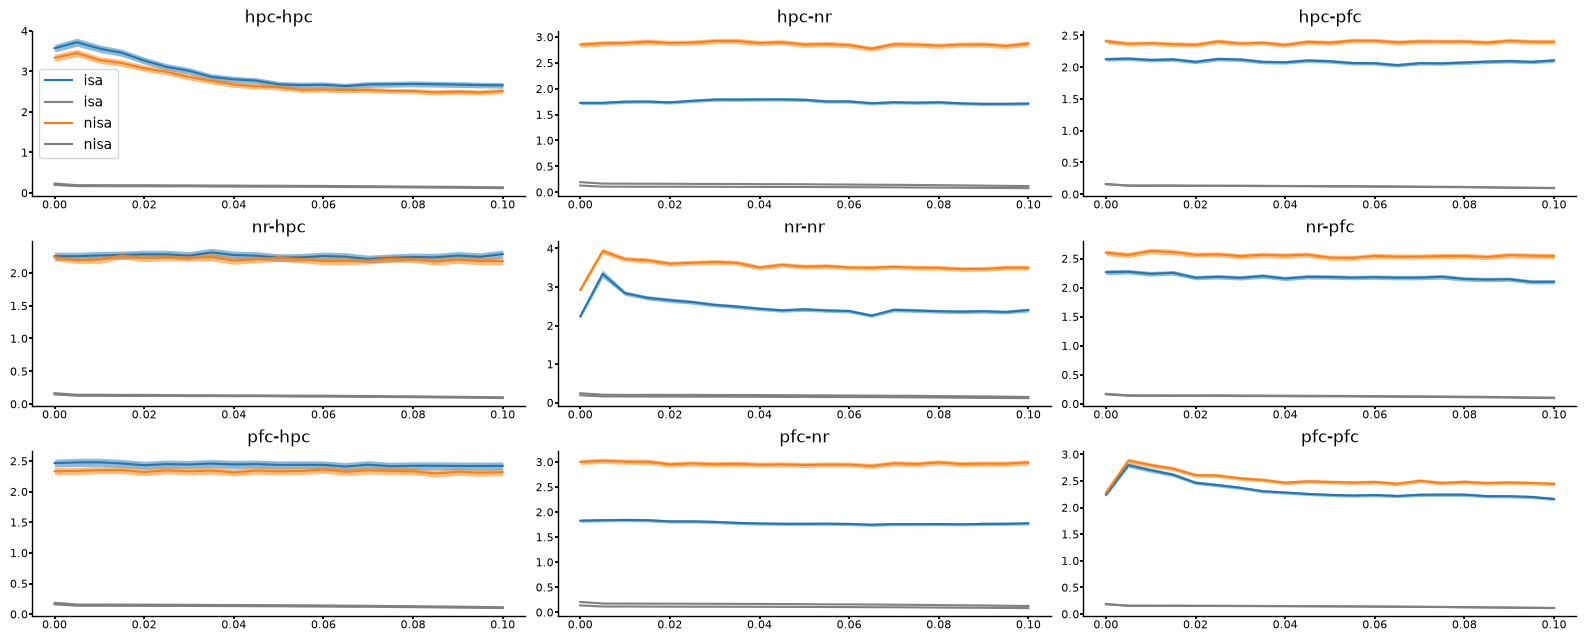

In [15]:
# average CCG
#conditions = ['nrem','rem','wake']
conditions = ['isa','nisa']
#conditions = sccg.cond.values[2:]
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(n=(n_regs,n_regs),size=(40,16))
for cond in conditions:
    for i, r0 in enumerate(regs):
        for j, r1 in enumerate(regs):
            ax[i,j].set(title=f'{r0}-{r1}')

            c = sccg.sel(cond=cond,shuf=False).sel(reg0=r0,reg1=r1)
            c = c.values.reshape(-1,c.shape[-1])
            fma.plotting.semPlot(sccg.t,c,ax=ax[i,j],label=cond)

            c = sccg.sel(cond=cond,shuf=True).sel(reg0=r0,reg1=r1).mean(dim='shuf')
            c = c.values.reshape(-1,c.shape[-1])
            fma.plotting.semPlot(sccg.t,c,ax=ax[i,j],label=cond,color='gray')
ax[0,0].legend();

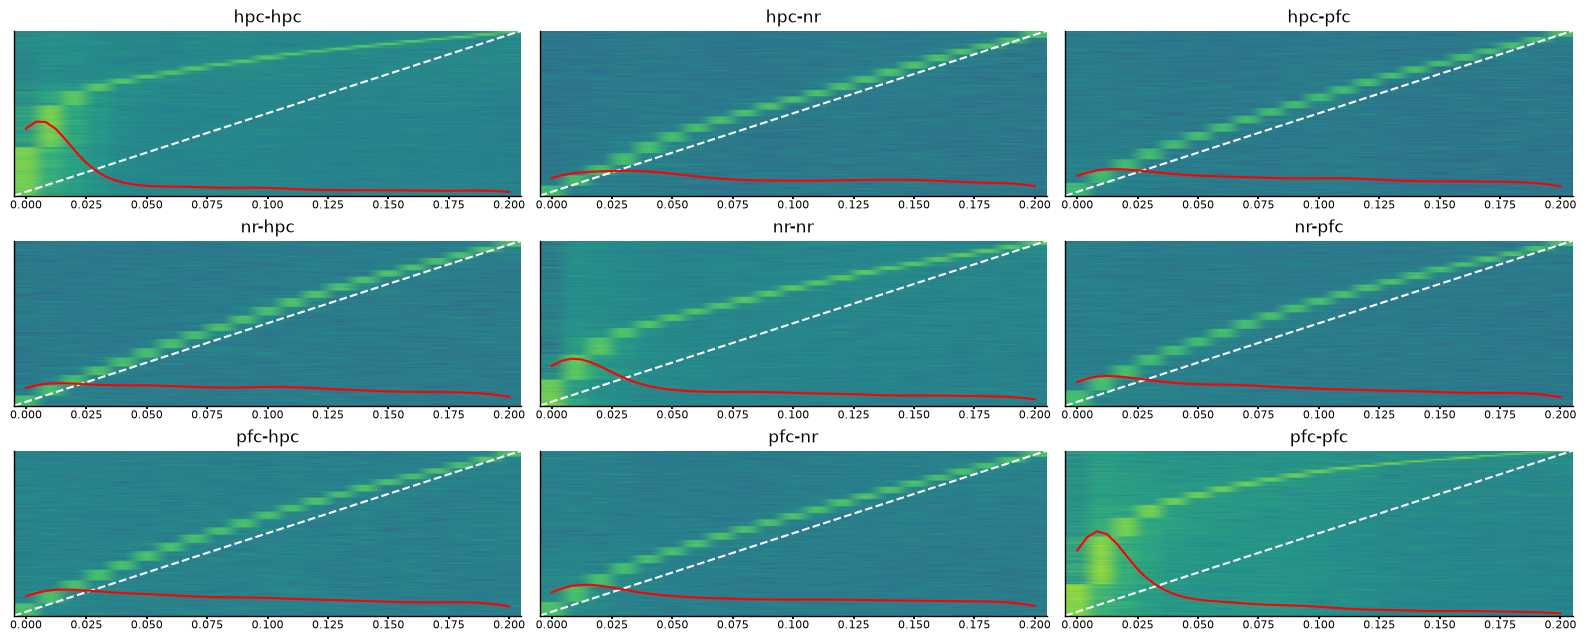

In [4]:
# note: only within-region count CCGs should satisfy t, -t symmetry
cond = 'isa'
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(n=(n_regs,n_regs),size=(40,16))
for i, r0 in enumerate(regs):
        for j, r1 in enumerate(regs):
            ax[i,j].set(title=f'{r0}-{r1}')

            c = sccg.sel(cond=cond).sel(reg0=r0,reg1=r1)
            c = c.values.reshape(-1,c.shape[-1])

            fma.plotting.plotColorMap(c,x=sccg.t,ax=ax[i,j],zscore=1,omitnan=1,sortby='peak')
            ax[i,j].plot(ax[i,j].get_xlim(),ax[i,j].get_ylim(),color='w',ls='--')

            peaks = sccg.t.values[np.argmax(c,axis=1)]
            x, y = fma.plotting.plotPDF(peaks,color='none',ax=ax[i,j])
            ax[i,j].plot(x[0],y[0]*100,color='r')

run batch

In [71]:
regs = ['hpc','nr','pfc']
bin = 0.005
ccg, peak_t = fma.data.runBatch(batch_file,_unitCCG,kwargs={'conds': ['isa','nisa'], 'regs': regs, 'shuffle': 500, 'bin': bin},parallel=True)


Starting Batch, 2026-08-28 11:40:11.246878 

Error in session /mnt/hubel-data-139/karadoc/Rat004_20240303/Rat004_20240303.xml (17)
zero-size array to reduction operation maximum which has no identity
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
list indices must be integers or slices, not tuple
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816

False

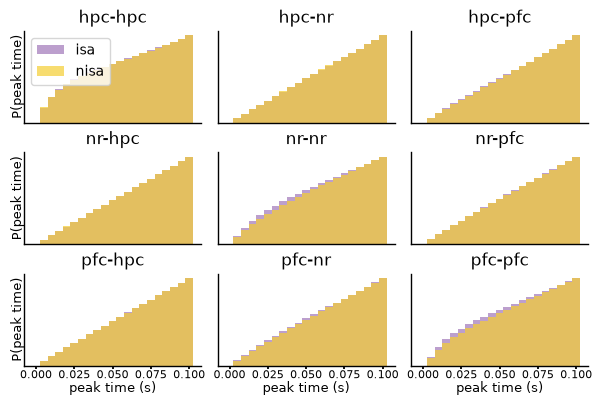

In [32]:
# plot peak times
cond = ['isa','nisa']
colors = ['nr','shuffl']
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(n=(n_regs,n_regs),size=(15,10))
for k, c in enumerate(cond):
    for i, r0 in enumerate(regs):
        for j, r1 in enumerate(regs):
            ax[i,j].set(title=f'{r0}-{r1}')
            print(f'{r0}-{r1} ',end='')
            data = []
            for l, p in enumerate(peak_t):
                if p is not None:
                    data.append(p.sel(cond=c,reg0=r0,reg1=r1,shuf=False).values.ravel()[p.signif.sel(cond=c,reg0=r0,reg1=r1).values.ravel()])
            data = np.concatenate(data)
            print(f'{len(data)} ',end='')
            x, y = fma.plotting.plotPDF(data,method='discrete',ax=ax[i,j],color=isau.paperColors(colors[k]),label=c,norm='cdf')
        print()
ax[0,0].legend(); fma.plotting.setProp(ax[:-1],xticks=[]); fma.plotting.setProp(ax[-1],xlabel='peak time (s)'); fma.plotting.setProp(ax[:,0],ylabel='P(peak time)')
do_save and fma.plotting.saveFigure(fig,froot / 'unitCCG',['png','svg'])

False

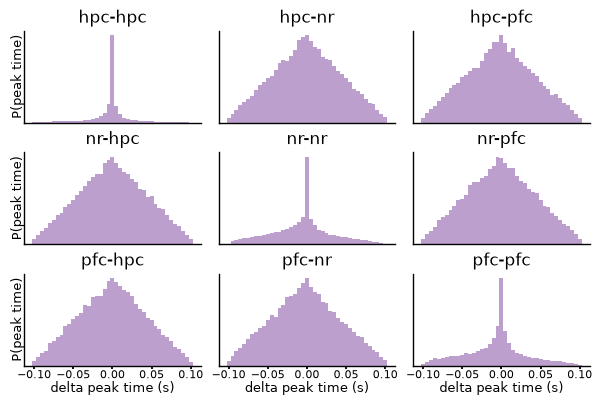

In [61]:
# plot delta peak times
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(n=(n_regs,n_regs),size=(15,10))
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        ax[i,j].set(title=f'{r0}-{r1}')
        data = []
        for l, p in enumerate(peak_t):
            if p is not None:
                _p = p.sel(cond=['isa','nisa'],reg0=r0,reg1=r1).values[:,signif[l].sel(cond='isa',reg0=r0,reg1=r1).values] # CANNOT SUBTRACT WITH != signif
                data.append( np.round((_p[0] - _p[1]),5) )
        x, y = fma.plotting.plotPDF(np.concatenate(data),method='discrete',ax=ax[i,j],color=isau.paperColors('nr'),norm='density')
fma.plotting.setProp(ax[:-1],xticks=[]); fma.plotting.setProp(ax[-1],xlabel='delta peak time (s)'); fma.plotting.setProp(ax[:,0],ylabel='P(peak time)')
do_save and fma.plotting.saveFigure(fig,froot / 'unitCCG',['png','svg'])

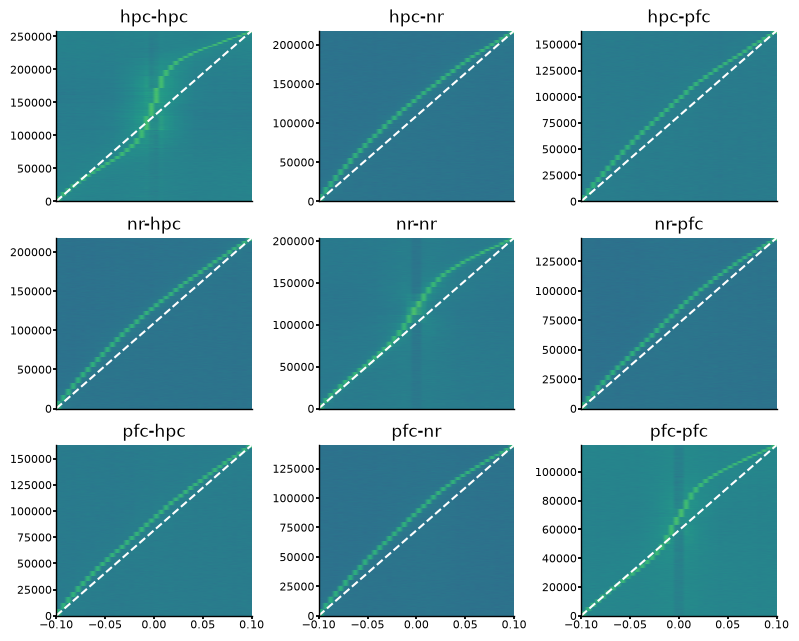

In [7]:
# note: only within-region count CCGs should satisfy t, -t symmetry
cond = 'isa'
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(n=(n_regs,n_regs),size=(20,16))
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        ax[i,j].set(title=f'{r0}-{r1}')

        data = []
        for cc in ccg:
            if cc is not None:
                c = cc.sel(cond=cond,reg0=r0,reg1=r1)
                data.append(c.values.reshape(-1,c.shape[-1]))

        fma.plotting.plotColorMap(np.concatenate(data),x=ccg[0].t,ax=ax[i,j],zscore=1,omitnan=1,sortby='peak')
        ax[i,j].plot(ax[i,j].get_xlim(),ax[i,j].get_ylim(),color='w',ls='--')
fma.plotting.setProp(ax[:-1],xticks=[])